Notebook 4

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import cv2

import torch
import torch.nn as nn
from torchvision import models, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.models import ResNet18_Weights


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
print(f'Using device: {device_name}')
device = torch.device(device_name)

Using device: mps


Build Model

In [3]:
ckpt_path = "models/cnn_division_classifier.pth"
ckpt = torch.load(ckpt_path, map_location=device_name)

id2label = ckpt["id2label"]
label2id = ckpt["label2id"]
num_classes = len(id2label)

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(ckpt["state_dict"])
model = model.to(device_name).eval()

print("Loaded model with classes:", id2label)

Loaded model with classes: {0: 'advanced', 1: 'allstar', 2: 'champion', 3: 'intermediate', 4: 'novice'}


Load Test Data

In [4]:
labels_df = pd.read_csv("../data/labels.csv")

image_paths = []
true_labels = []

for idx, row in labels_df.iterrows():
    folder = f"../data/frames_2/{row['division']}/{row['division']}_{row['id']}"
    for img_path in Path(folder).glob("*.jpg"):
        image_paths.append(str(img_path))
        true_labels.append(label2id[row['division']])
        
print(f"Loaded {len(image_paths)} frames from {len(labels_df)} videos")

Loaded 236 frames from 20 videos


Transform

In [5]:
tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loaded", len(image_paths), "frames")

Loaded 236 frames


Making Predictions

In [6]:
preds = []

with torch.no_grad():
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        x = tfm(img).unsqueeze(0).to(device_name)
        logits = model(x)
        pred = logits.argmax(dim=1).item()
        preds.append(pred)
        

Confusion Matrix

<Figure size 600x500 with 0 Axes>

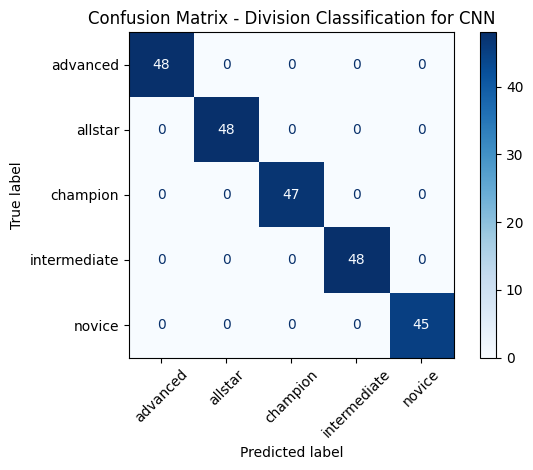

In [7]:

classes = sorted(id2label.keys()) 
cm = confusion_matrix(true_labels, preds, labels=classes)

display_labels = [id2label[c] for c in classes]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
plt.figure(figsize=(6,5))

disp.plot(cmap='Blues', values_format="d", xticks_rotation=45)

if cm.max() == cm.min():
    disp.im_.set_clim(0, cm.max() + 1)

plt.title("Confusion Matrix - Division Classification for CNN")
plt.tight_layout()
plt.show()

Misclassified Examples

In [8]:
mis_idx = [i for i in range(len(preds)) if preds[i] != true_labels[i]]

print("number of misclassified examples:", len(mis_idx))

def show_misclassified(n=6):
    plt.figure(figsize=(15, 5))
    for i in mis_idx[:n]:
        img = Image.open(image_paths[i]).convert("RGB")
        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True: {id2label[true_labels[i]]}, Pred: {id2label[preds[i]]}")
        plt.show()
       

number of misclassified examples: 0


Grad-CAM Implementation and Grad_CAM heatmap

In [9]:
gradients = None
activations = None
def save_gradients(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

def save_activations(module, input, output):
    global activations
    activations = output

target_layer = model.layer4[-1].conv2
target_layer.register_forward_hook(save_activations)
target_layer.register_backward_hook(save_gradients)

# heatmap
def generate_gradcam(input_tensor, class_idx):
    model.zero_grad()
    out = model(input_tensor)
    loss = out[0, class_idx]
    loss.backward()

    global activations, gradients
    weights = gradients.mean(dim=[2, 3], keepdim=True) 
    cam = (weights * activations).sum(dim=1, keepdim=True)

    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)

    return cam.squeeze().cpu().detach().numpy()

Visualize Grad-CAM Overlay

In [10]:
def show_gradcam(image_path, true_label=None):
    img = Image.open(image_path).convert("RGB")
    inp = tfm(img).unsqueeze(0).to(device)

    pred = model(inp).argmax(1).item()
    cam = generate_gradcam(inp, pred)

    cam_resized = cv2.resize(cam, (224, 224))
    img_resized = img.resize((224, 224))
    img_np = np.array(img_resized)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay
    overlay = np.float32(heatmap) / 255 + np.float32(img_np) / 255
    overlay = overlay / np.max(overlay)

    plt.figure(figsize=(9,4))
    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title(f"Original\nTrue: {true_label}")

    plt.subplot(1,3,2)
    plt.imshow(heatmap)
    plt.title("Grad-CAM Heatmap")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPred: {id2label[pred]}")
    plt.show()

Apply Grad-CAM to some correct & incorrect frames

Showing Grad-CAM for a correctly classified frame (236 correct predictions)


/Volumes/System/Projects/CS171_project/venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


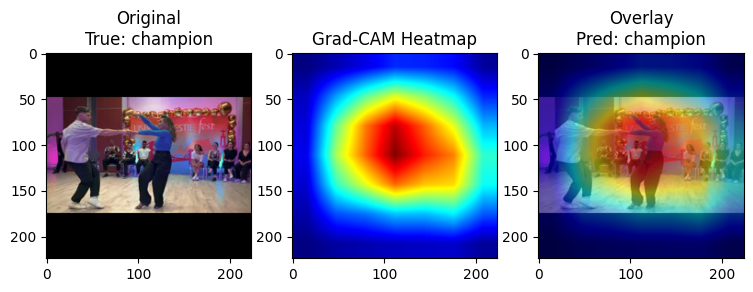

No misclassified examples found - all predictions were correct!


In [11]:
# Get indices for correct predictions
correct_idx = [i for i in range(len(preds)) if preds[i] == true_labels[i]]

if len(correct_idx) > 0:
    print(f"Showing Grad-CAM for a correctly classified frame ({len(correct_idx)} correct predictions)")
    show_gradcam(image_paths[correct_idx[0]], id2label[true_labels[correct_idx[0]]])
else:
    print("No correct predictions found!")

if len(mis_idx) > 0:
    print(f"\nShowing Grad-CAM for a misclassified frame ({len(mis_idx)} misclassified)")
    show_gradcam(image_paths[mis_idx[0]], id2label[true_labels[mis_idx[0]]])
else:
    print("No misclassified examples found - all predictions were correct!")

Division-Level Accuracy - to answer the question if the higher divisions show more consistent SUgar Push/Sugar Tag patterns

/var/folders/fm/7_tgq2_150x33y8wsm_48kkm0000gn/T/ipykernel_55517/2265318956.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  division_acc = results_df.groupby("division").apply(


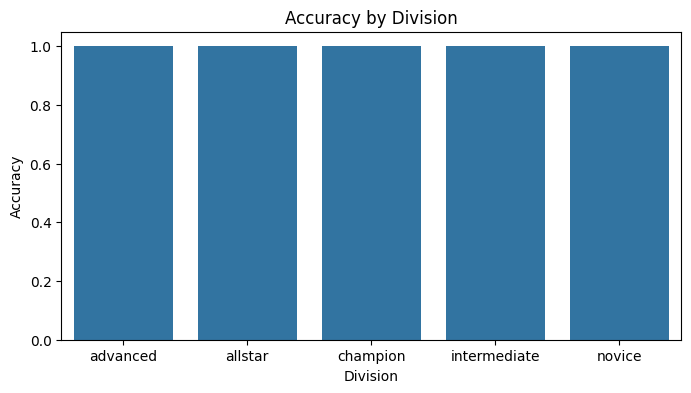

In [12]:
# Create a DataFrame for frame-level results since preds are per-frame
results_df = pd.DataFrame({
    "true_label": true_labels,
    "pred": preds,
    "path": image_paths
})

# Extract division from path
# Path structure: .../frames/<division>/<video_folder>/<image.jpg>
results_df["division"] = results_df["path"].apply(lambda x: Path(x).parent.parent.name)

# Calculate accuracy
division_acc = results_df.groupby("division").apply(
    lambda x: np.mean(x["pred"] == x["true_label"])
)

plt.figure(figsize=(8,4))
sns.barplot(x=division_acc.index, y=division_acc.values)
plt.title("Accuracy by Division")
plt.ylabel("Accuracy")
plt.xlabel("Division")
plt.show()

<!-- TO DO : add interpretations of results after adding more data -->